# Video Temporal Deepfake Training

Train the temporal consistency classifier for video deepfake detection. Outputs models/vision/video_temporal_model.pkl.


In [1]:
from pathlib import Path
import sys

repo_root = Path.cwd().resolve()
for cand in [repo_root, *repo_root.parents]:
    if (cand / 'app').exists():
        repo_root = cand
        break
sys.path.insert(0, str(repo_root))
print('Repo root:', repo_root)


Repo root: /Users/pratik_n/Desktop/MyComputer/Sentifargo


## Data requirements

Provide videos under data/raw/vision/video/real and data/raw/vision/video/fake. FFmpeg must be available on PATH.


## Dataset inventory


In [2]:
from pathlib import Path

real_dir = repo_root / 'data' / 'raw' / 'vision' / 'video' / 'real'
fake_dir = repo_root / 'data' / 'raw' / 'vision' / 'video' / 'fake'
print('Real dir:', real_dir, 'exists=', real_dir.exists())
print('Fake dir:', fake_dir, 'exists=', fake_dir.exists())

def _count_videos(path):
    if not path.exists():
        return 0
    return sum(1 for p in path.rglob('*') if p.suffix.lower() in {'.mp4', '.mov', '.avi', '.mkv', '.webm'})

print('Real videos:', _count_videos(real_dir))
print('Fake videos:', _count_videos(fake_dir))


Real dir: /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/raw/vision/video/real exists= True
Fake dir: /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/raw/vision/video/fake exists= True
Real videos: 890
Fake videos: 5639


## Links to code


- Training script: `src/train/train_video_temporal.py`


- Vision resnet: `src/uais_v/models/vision_resnet.py`


In [3]:
# Update paths if your data lives elsewhere.



In [4]:
real_dir = repo_root / 'data' / 'raw' / 'vision' / 'video' / 'real'
fake_dir = repo_root / 'data' / 'raw' / 'vision' / 'video' / 'fake'
print('Real dir:', real_dir.exists(), real_dir)
print('Fake dir:', fake_dir.exists(), fake_dir)


Real dir: True /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/raw/vision/video/real
Fake dir: True /Users/pratik_n/Desktop/MyComputer/Sentifargo/data/raw/vision/video/fake


## Train the temporal model


In [5]:
# !python -m src.train.train_video_temporal --real-dir data/raw/vision/video/real --fake-dir data/raw/vision/video/fake


## Confirm artifacts


In [6]:
artifact = repo_root / 'models' / 'vision' / 'video_temporal_model.pkl'
print('Model saved:', artifact.exists(), artifact)


Model saved: True /Users/pratik_n/Desktop/MyComputer/Sentifargo/models/vision/video_temporal_model.pkl


## Visuals and metrics


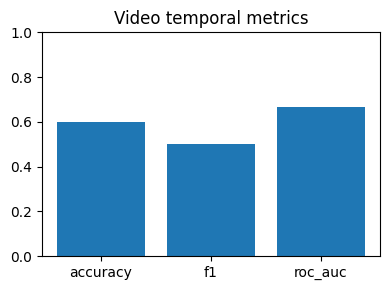

In [7]:
import json
import matplotlib.pyplot as plt
from pathlib import Path

metrics_path = repo_root / 'experiments' / 'vision' / 'video_temporal' / 'metrics.json'
if not metrics_path.exists():
    print('Metrics not found:', metrics_path)
else:
    metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
    keys = ['accuracy', 'f1', 'roc_auc']
    values = [metrics.get(k) for k in keys]
    plt.figure(figsize=(4, 3))
    plt.bar(keys, values)
    plt.ylim(0, 1)
    plt.title('Video temporal metrics')
    plt.tight_layout()
    plt.show()


In [ ]:
# METRICS_EXPORT_VIDEO
import json
import pandas as pd
from pathlib import Path

metrics_path = repo_root / 'experiments' / 'vision' / 'video_temporal' / 'metrics.json'
rows = []
if metrics_path.exists():
    metrics = json.loads(metrics_path.read_text(encoding='utf-8'))
    for key in ['accuracy', 'f1', 'roc_auc']:
        if key in metrics:
            rows.append({'Metric': key, 'mean': float(metrics.get(key, 0.0)), 'std': ''})

report_path = repo_root / 'reports' / 'metrics_video.csv'
df_new = pd.DataFrame(rows)
if report_path.exists():
    df_old = pd.read_csv(report_path)
    if 'std' not in df_old.columns:
        df_old['std'] = ''
    df_old = df_old[~df_old['Metric'].isin(df_new['Metric'])]
    df_out = pd.concat([df_old, df_new], ignore_index=True)
else:
    df_out = df_new
report_path.parent.mkdir(parents=True, exist_ok=True)
df_out.to_csv(report_path, index=False)
print('Saved metrics to', report_path)
